In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Hyperparameters
BATCH_SIZE   = 64
LR           = 2e-4
B1, B2       = 0.5, 0.999
NOISE_SIZE   = 100
HIDDEN_SIZE  = 256
NUM_CLASSES  = 10
EPOCHS       = 100
DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

In [4]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.label_emb = nn.Embedding(NUM_CLASSES, NUM_CLASSES)
        self.net = nn.Sequential(
            nn.Linear(NOISE_SIZE + NUM_CLASSES, HIDDEN_SIZE),
            nn.ReLU(),
            nn.Linear(HIDDEN_SIZE, HIDDEN_SIZE * 2),
            nn.BatchNorm1d(HIDDEN_SIZE * 2),
            nn.ReLU(),
            nn.Linear(HIDDEN_SIZE * 2, HIDDEN_SIZE * 4),
            nn.BatchNorm1d(HIDDEN_SIZE * 4),
            nn.ReLU(),
            nn.Linear(HIDDEN_SIZE * 4, 28 * 28),
            nn.Tanh(),
        )

    def forward(self, z, labels):
        x = torch.cat([z, self.label_emb(labels)], dim=1)
        return self.net(x).view(-1, 1, 28, 28)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.label_emb = nn.Embedding(NUM_CLASSES, NUM_CLASSES)
        self.net = nn.Sequential(
            nn.Linear(28 * 28 + NUM_CLASSES, HIDDEN_SIZE * 4),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(HIDDEN_SIZE * 4, HIDDEN_SIZE * 2),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(HIDDEN_SIZE * 2, HIDDEN_SIZE),
            nn.LeakyReLU(0.2),
            nn.Linear(HIDDEN_SIZE, 1),
            nn.Sigmoid(),
        )

    def forward(self, img, labels):
        x = torch.cat([img.view(-1, 28 * 28), self.label_emb(labels)], dim=1)
        return self.net(x)

In [5]:
G = Generator().to(DEVICE)
D = Discriminator().to(DEVICE)

criterion = nn.BCELoss()
opt_G = torch.optim.Adam(G.parameters(), lr=LR, betas=(B1, B2))
opt_D = torch.optim.Adam(D.parameters(), lr=LR, betas=(B1, B2))

# 시각화용 고정 noise — 같은 z로 epoch마다 진행 상황 추적
fixed_z      = torch.randn(NUM_CLASSES * 10, NOISE_SIZE, device=DEVICE)
fixed_labels = torch.arange(NUM_CLASSES, device=DEVICE).repeat_interleave(10)

In [6]:
def visualize(epoch):
    G.eval()
    with torch.no_grad():
        imgs = G(fixed_z, fixed_labels)   # (100, 1, 28, 28)
    G.train()

    grid = make_grid(imgs, nrow=10, normalize=True, value_range=(-1, 1))
    plt.figure(figsize=(10, 10))
    plt.imshow(grid.permute(1, 2, 0).cpu(), cmap='gray')
    plt.title(f'Epoch {epoch}  |  rows: digits 0-9  /  cols: 10 samples each')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [ ]:
for epoch in range(1, EPOCHS + 1):
    g_losses, d_losses = [], []

    for real_imgs, labels in loader:
        real_imgs, labels = real_imgs.to(DEVICE), labels.to(DEVICE)
        bs = real_imgs.size(0)

        real_t = torch.ones(bs, 1, device=DEVICE)
        fake_t = torch.zeros(bs, 1, device=DEVICE)

        # Discriminator
        z    = torch.randn(bs, NOISE_SIZE, device=DEVICE)
        fake = G(z, labels).detach()
        loss_D = (
            criterion(D(real_imgs, labels), real_t) +
            criterion(D(fake, labels),      fake_t)
        )
        opt_D.zero_grad(); loss_D.backward(); opt_D.step()

        # Generator
        z    = torch.randn(bs, NOISE_SIZE, device=DEVICE)
        fake = G(z, labels)
        loss_G = criterion(D(fake, labels), real_t)
        opt_G.zero_grad(); loss_G.backward(); opt_G.step()

        g_losses.append(loss_G.item())
        d_losses.append(loss_D.item())

    print(f'Epoch [{epoch:3d}/{EPOCHS}]  D_loss: {np.mean(d_losses):.4f}  G_loss: {np.mean(g_losses):.4f}')
    visualize(epoch)

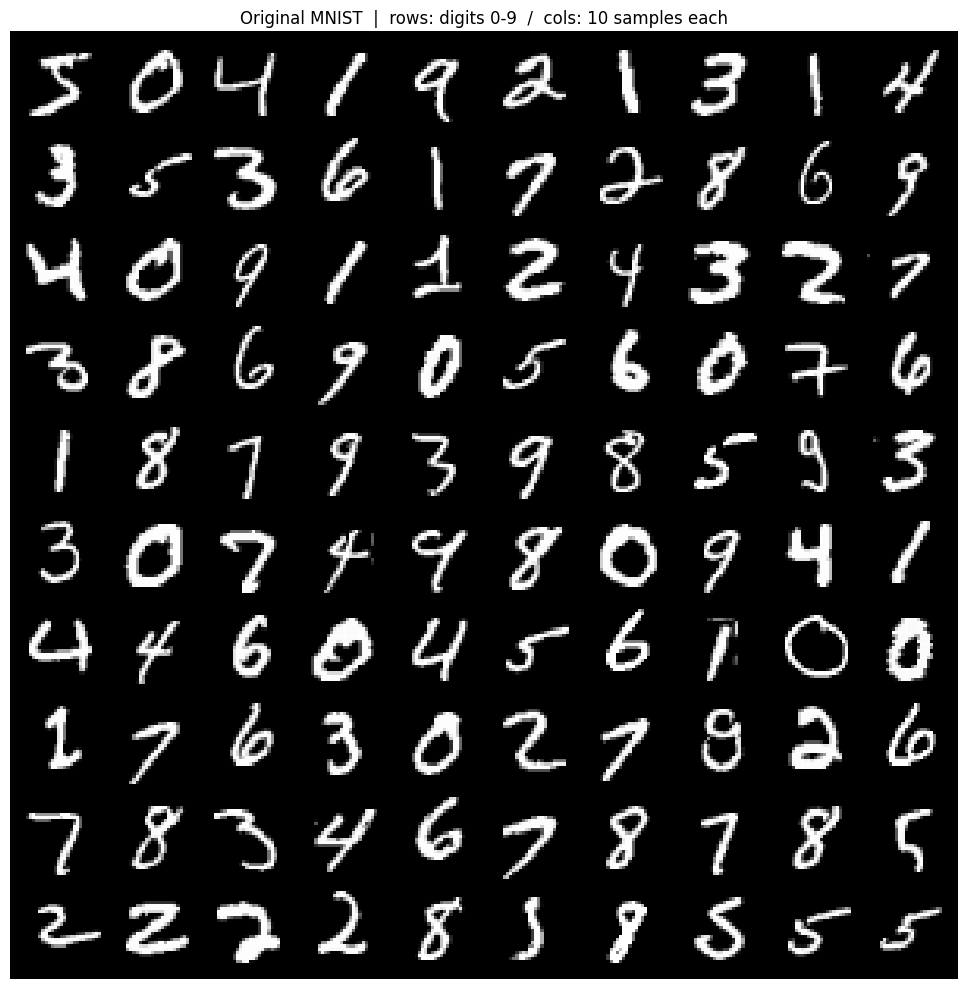

In [8]:
# 원본 MNIST 샘플 — 각 숫자(0-9)를 10개씩
raw_dataset = datasets.MNIST(root='./data', train=True, download=False,
                              transform=transforms.ToTensor())
orig_imgs = []
counts = {i: 0 for i in range(NUM_CLASSES)}

for img, label in raw_dataset:
    if counts[label] < 10:
        orig_imgs.append(img)
        counts[label] += 1
    if all(v == 10 for v in counts.values()):
        break

grid = make_grid(torch.stack(orig_imgs), nrow=10)
plt.figure(figsize=(10, 10))
plt.imshow(grid.permute(1, 2, 0), cmap='gray')
plt.title('Original MNIST  |  rows: digits 0-9  /  cols: 10 samples each')
plt.axis('off')
plt.tight_layout()
plt.show()